<a href="https://colab.research.google.com/github/Emo4ka07/VKR/blob/main/NTP_%D1%83%D0%B6_%D1%81_%D0%B5%D0%B6%D0%BE%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import random
import numpy as np
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt

In [ ]:
# время / сетка
T = 500.0
N = 2000
ts = np.linspace(0.0, T, N).astype(np.float32)
dt = ts[1] - ts[0]

X_SCALE = 1000.0
C_SCALE = 1000.0
U_MAX = 500.0
ALPHA_U = 0.001   # штраф на энергию управления (в нормированной шкале)

# индексы
control_idx = 1
target_idx = 1

# параметры системы
system_params = {
    "a1": 0.002, "a2": 0.001, "b1": 0.49, "r1": 0.4632, "r2": 0.4425,
    "K1": 505.0, "K2": 505.0, "w1": 0.6625, "w2": 0.435,
    "d1": 45.0, "d2": 30.0, "g1": 0.516, "g2": 0.45,
    "m": 0.309, "m1": 0.001
}

class Controller(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # слои
        self.d1 = tf.keras.layers.Dense(32, activation='tanh')
        self.d2 = tf.keras.layers.Dense(64, activation='tanh')
        self.gru1 = tf.keras.layers.GRUCell(32, activation='tanh')
        self.gru2 = tf.keras.layers.GRUCell(32, activation='tanh')
        self.d3 = tf.keras.layers.Dense(32, activation='tanh')
        self.d4 = tf.keras.layers.Dense(16, activation='tanh')
        self.out = tf.keras.layers.Dense(1, activation='tanh')  # нормированное u в [-1,1]

    # основной шаг контроллера
    # x_norm: (batch,3) уже нормированное X_SCALE, C_norm: (batch,1)
    def step(self, x_norm, C_norm, h1, h2):
        inp = tf.concat([x_norm, C_norm], axis=-1)  # (batch,4)
        z = self.d1(inp)
        z = self.d2(z)
        o1, [h1_new] = self.gru1(z, [h1])
        o2, [h2_new] = self.gru2(o1, [h2])
        y = self.d3(o2)
        y = self.d4(y)
        u_norm = tf.squeeze(self.out(y), axis=-1)  # (batch,)
        return u_norm, h1_new, h2_new

    def call(self, inputs):
        """
        inputs = tuple(x_norm, C_norm, h1, h2)
        возвращает u_norm, h1_new, h2_new
        """
        x_norm, C_norm, h1, h2 = inputs
        return self.step(x_norm, C_norm, h1, h2)


# динамика (использует raw x и реальный u_scaled)
def dynamics(x, u_scaled, p):
    # x: (batch,3), u_scaled: (batch,) or scalar
    a1, a2, b1 = p["a1"], p["a2"], p["b1"]
    r1, r2, K1, K2 = p["r1"], p["r2"], p["K1"], p["K2"]
    w1, w2, d1, d2 = p["w1"], p["w2"], p["d1"], p["d2"]
    g1, g2, m, m1 = p["g1"], p["g2"], p["m"], p["m1"]

    x1 = x[...,0]; x2 = x[...,1]; x3 = x[...,2]
    dx1 = r1*x1*(1-(x1+a1*x2)/K1) - (w1*x1*x3)/(d1 + x1)
    dx2 = r2*x2*(1-(x2+a2*x1)/K2) - (w2*x2*x3)/(d2 + b1*x2**2)
    dx3 = (g1*x1*x3)/(d1 + x1) - (g2*x2*x3)/(d2 + b1*x2**2) - m*x3 - m1*x3**2

    # добавляем управление в нужную компоненту
    u = tf.reshape(u_scaled, tf.shape(x1))
    if control_idx == 0:
        dx = tf.stack([dx1 + u, dx2, dx3], axis=-1)
    elif control_idx == 1:
        dx = tf.stack([dx1, dx2 + u, dx3], axis=-1)
    else:
        dx = tf.stack([dx1, dx2, dx3 + u], axis=-1)

    dx = tf.clip_by_value(dx, -1e6, 1e6)  # защита
    return dx

def rk4_step(x, h1, h2, controller, C_raw, params, dt):
    C_norm = C_raw / C_SCALE  # (batch,1)

    def f(xi, h1i, h2i):
        xi_norm = xi / X_SCALE
        u_norm, h1n, h2n = controller.step(xi_norm, C_norm, h1i, h2i)
        u_scaled = u_norm * U_MAX
        dx = dynamics(xi, u_scaled, params)
        return dx, h1n - h1i, h2n - h2i, u_norm

    k1x, k1h1, k1h2, u1 = f(x, h1, h2)
    k2x, k2h1, k2h2, _  = f(x + 0.5*dt*k1x, h1 + 0.5*dt*k1h1, h2 + 0.5*dt*k1h2)
    k3x, k3h1, k3h2, _  = f(x + 0.5*dt*k2x, h1 + 0.5*dt*k2h1, h2 + 0.5*dt*k2h2)
    k4x, k4h1, k4h2, _  = f(x + dt*k3x,     h1 + dt*k3h1,     h2 + dt*k3h2)

    x_next  = x  + (dt/6.0)*(k1x  + 2.0*k2x  + 2.0*k3x  + k4x)
    h1_next = h1 + (dt/6.0)*(k1h1 + 2.0*k2h1 + 2.0*k3h1 + k4h1)
    h2_next = h2 + (dt/6.0)*(k1h2 + 2.0*k2h2 + 2.0*k3h2 + k4h2)

    # защита от взрывов (устранить слишком большие/отрицательные значения)
    x_next = tf.clip_by_value(x_next, -1e6, 1e6)
    return x_next, h1_next, h2_next, u1

@tf.function
def simulate_batch(x0_raw, C_raw, controller, params):
    batch = tf.shape(x0_raw)[0]
    units = 32
    h1 = tf.zeros([batch, units])
    h2 = tf.zeros([batch, units])
    x = x0_raw
    traj = tf.TensorArray(tf.float32, size=N)
    u_stack = tf.TensorArray(tf.float32, size=N)
    for i in tf.range(N):
        x, h1, h2, u_norm = rk4_step(x, h1, h2, controller, C_raw, params, dt)
        traj = traj.write(i, x)
        u_stack = u_stack.write(i, u_norm)
    traj_ = tf.transpose(traj.stack(), perm=[1, 0, 2])
    u_stack_ = tf.transpose(u_stack.stack(), perm=[1, 0])
    return traj_, u_stack_

def batch_loss(controller, x0_raw, C_raw, params):
    traj, u_stack = simulate_batch(x0_raw, C_raw, controller, params)
    target_traj = traj[:, :, target_idx]  # (batch, steps)
    C_expand = tf.squeeze(C_raw, axis=-1)[:, tf.newaxis]  # (batch, 1)

    # ошибка в реальных величинах
    err = target_traj - C_expand
    mse = tf.reduce_mean(tf.square(err))

    # штраф за энергию управления (нормированное u)
    u_pen = tf.reduce_mean(tf.square(u_stack))

    # суммарная функция потерь
    loss = mse + ALPHA_U * u_pen
    return loss


В следующей ячейке обучение

Epoch   1 | Train=56890.246094 | Test=49518.121094
Epoch  10 | Train=15427803136.000000 | Test=19644497920.000000
Epoch  20 | Train=1143930496.000000 | Test=5246.574707
Epoch  30 | Train=3717.208740 | Test=3006.820068
Epoch  40 | Train=3341.654785 | Test=2737.600830
Epoch  50 | Train=3226.204346 | Test=2676.639404
Веса сохранены в /content/drive/MyDrive/controller_weights.weights.h5


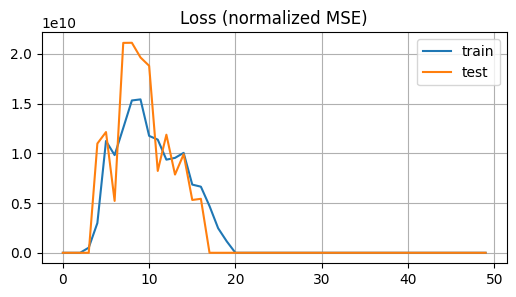

In [ ]:
# данные
def make_samples(n):
    xs = np.random.uniform(10.0, 900.0, size=(n,3)).astype(np.float32)
    Cs = np.random.uniform(100.0, 1000.0, size=(n,1)).astype(np.float32)
    return xs, Cs

np.random.seed(13)
train_xs, train_Cs = make_samples(500)
test_xs, test_Cs   = make_samples(100)

BATCH_SIZE = 16
train_dataset = tf.data.Dataset.from_tensor_slices((train_xs, train_Cs)).shuffle(len(train_xs)).batch(BATCH_SIZE)
test_dataset  = tf.data.Dataset.from_tensor_slices((test_xs, test_Cs)).batch(BATCH_SIZE)

# создаем контроллер и инициализируем переменные
controller = Controller()
# dummy вызов, чтобы создать веса
_dummy_x = tf.zeros((1,3), dtype=tf.float32)
_dummy_C = tf.zeros((1,1), dtype=tf.float32)
_dummy_h = tf.zeros((1,32), dtype=tf.float32)
_ = controller.step(_dummy_x/_X_SCALE if False else _dummy_x/X_SCALE, _dummy_C/C_SCALE, _dummy_h, _dummy_h)  # вызов чтобы создать веса

# optimizer и параметры обучения
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
EPOCHS = 50

train_losses = []
test_losses = []

for epoch in range(1, EPOCHS+1):
    epoch_loss = 0.0
    nb = 0
    for bx, bC in train_dataset:
        with tf.GradientTape() as tape:
            loss = batch_loss(controller, bx, bC, system_params)
        grads = tape.gradient(loss, controller.trainable_variables)
        grads = [tf.clip_by_norm(g, 1.0) for g in grads]  # клипим нормы градиента
        optimizer.apply_gradients(zip(grads, controller.trainable_variables))
        epoch_loss += loss.numpy()
        nb += 1
    train_losses.append(epoch_loss / nb)

    # тест
    test_loss = 0.0
    nb_t = 0
    for tx, tC in test_dataset:
        l = batch_loss(controller, tx, tC, system_params)
        test_loss += l.numpy()
        nb_t += 1
    test_losses.append(test_loss / nb_t)

    if epoch % 10 == 0 or epoch==1:
        print(f"Epoch {epoch:3d} | Train={train_losses[-1]:.6f} | Test={test_losses[-1]:.6f}")

save_path = "/content/drive/MyDrive/controller_weights.weights.h5"

_dummy_x = tf.zeros((1,3), dtype=tf.float32)
_dummy_C = tf.zeros((1,1), dtype=tf.float32)
_dummy_h = tf.zeros((1,32), dtype=tf.float32)
controller.step(_dummy_x / X_SCALE, _dummy_C / C_SCALE, _dummy_h, _dummy_h)
controller.build(input_shape=[(1,3), (1,1), (1,32), (1,32)])  # 👈 важно
controller.save_weights(save_path)

# сохраняем веса

controller.save_weights(save_path)
print("Веса сохранены в", save_path)

# график потерь
plt.figure(figsize=(6,3))
plt.plot(train_losses, label='train')
plt.plot(np.linspace(0, EPOCHS-1, len(test_losses)), test_losses, label='test')
plt.legend(); plt.grid(); plt.title("Loss (normalized MSE)")
plt.show()

Запуск обученной модели, построение графиков

Веса успешно загружены


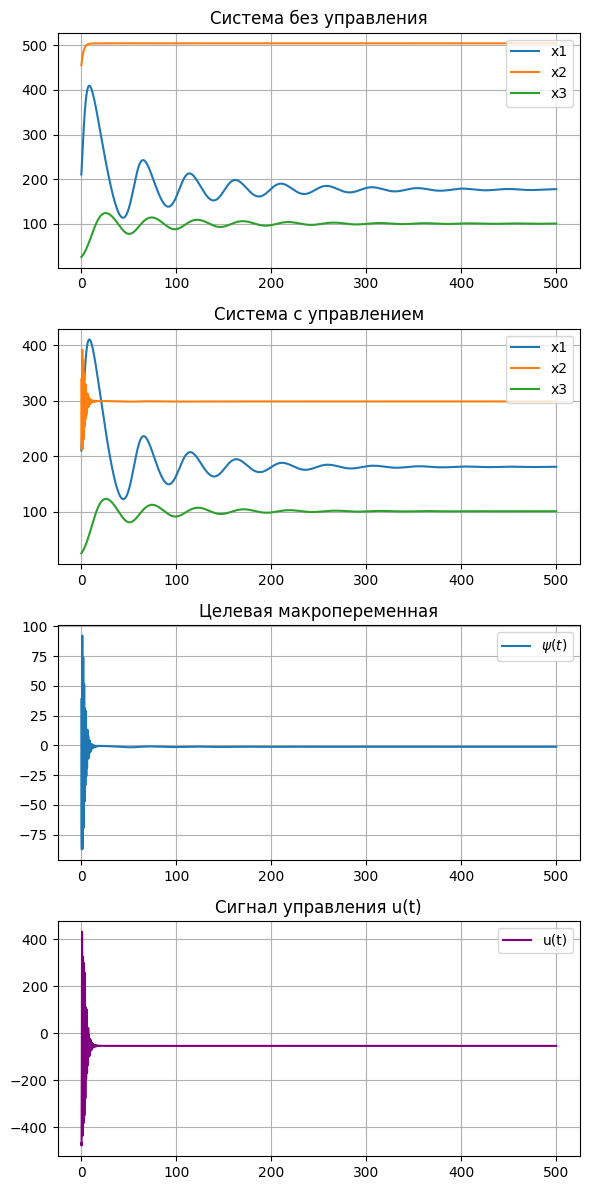

In [ ]:
controller = Controller()

# строим модель через call
_dummy_x = tf.zeros((1,3))
_dummy_C = tf.zeros((1,1))
_dummy_h = tf.zeros((1,32))
_ = controller((_dummy_x / X_SCALE, _dummy_C / C_SCALE, _dummy_h, _dummy_h))

# загружаем веса
controller.load_weights("/content/drive/MyDrive/controller_weights.weights.h5")
print("Веса успешно загружены")

def simulate_with_u(x0, C, controller, params):
    batch = tf.shape(x0)[0]
    h1 = tf.zeros([batch, 32]); h2 = tf.zeros([batch, 32])
    x = x0
    traj = tf.TensorArray(tf.float32, size=N)
    u_traj = tf.TensorArray(tf.float32, size=N)
    for i in tf.range(N):
        x_norm = x / X_SCALE
        C_norm = C / C_SCALE
        u_norm, h1, h2 = controller.step(x_norm, C_norm, h1, h2)   # normalized in
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, params)
        x = x + dt * dx
        traj = traj.write(i, x)
        u_traj = u_traj.write(i, u_scaled)   # сохраняем реальное u
    return tf.transpose(traj.stack(), [1,0,2]), tf.transpose(u_traj.stack(), [1,0])

# симуляция без управления
def simulate_no_control(x0, params):
    x = tf.identity(x0)
    traj = tf.TensorArray(tf.float32, size=N)
    for i in tf.range(N):
        dx = dynamics(x, tf.zeros((tf.shape(x)[0],)), params)
        x = x + dt * dx
        traj = traj.write(i, x)
    return tf.transpose(traj.stack(), [1,0,2])

# демонстрация
demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)                    # здесь можно поменять целевое значение

traj_no = simulate_no_control(demo_x, system_params).numpy()[0]
traj_ctrl, u_traj = simulate_with_u(demo_x, demo_C, controller, system_params)
traj_ctrl, u_traj = traj_ctrl.numpy()[0], u_traj.numpy()[0]
psi = traj_ctrl[:,1] - demo_C[0]

# графики
plt.figure(figsize=(6,12))

plt.subplot(4,1,1)
plt.plot(ts, traj_no[:,0], label='x1')
plt.plot(ts, traj_no[:,1], label='x2')
plt.plot(ts, traj_no[:,2], label='x3')
plt.title("Система без управления")
plt.grid(); plt.legend(loc='upper right')

plt.subplot(4,1,2)
plt.plot(ts, traj_ctrl[:,0], label='x1')
plt.plot(ts, traj_ctrl[:,1], label='x2')
plt.plot(ts, traj_ctrl[:,2], label='x3')
plt.title("Система с управлением")
plt.grid(); plt.legend(loc='upper right')

plt.subplot(4,1,3)
plt.plot(ts, psi, label=r'$\psi(t)$')
plt.title("Целевая макропеременная")
plt.grid(); plt.legend(loc='upper right')

plt.subplot(4,1,4)
plt.plot(ts, u_traj, label='u(t)', color='purple')
plt.title("Сигнал управления u(t)")
plt.grid(); plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

изменения C

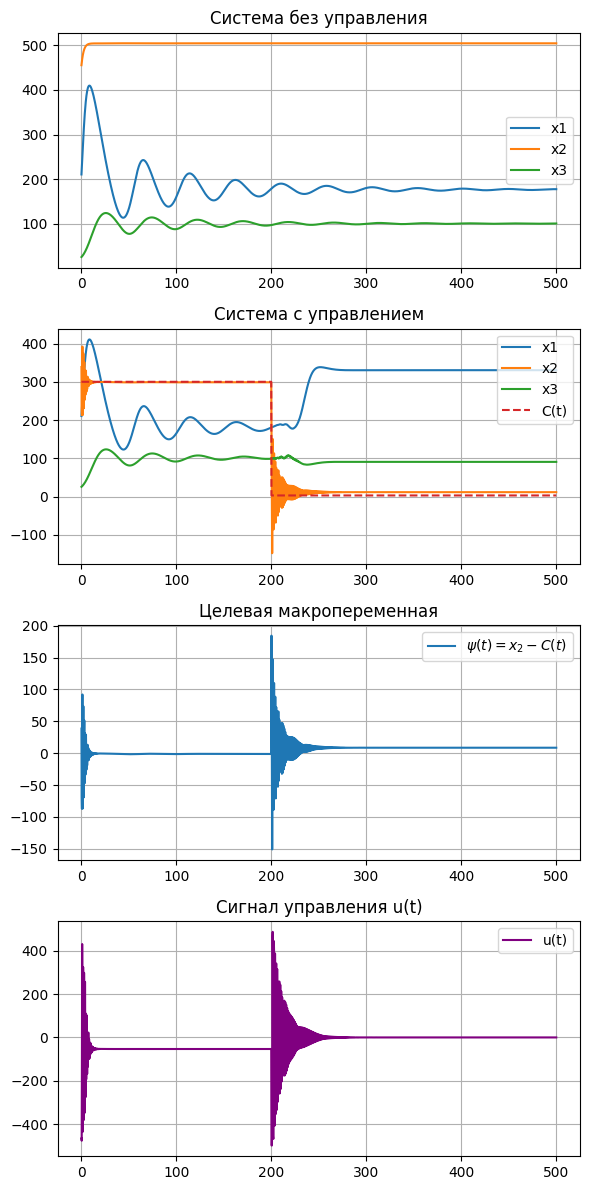

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

demo_x = np.array([[200.0, 450.0, 25.0]], np.float32)

# Параметры изменения C
C0 = 300.0        # начальное значение C
t_change = 200.0  # время, в котором произойдёт изменение
C_after = 3.0    # значение C после t_change

C_vals = np.full(shape=(len(ts),), fill_value=float(C0), dtype=np.float32)
C_vals[ts >= t_change] = float(C_after)

C_traj_np = C_vals.reshape((len(ts), 1, 1)).astype(np.float32)
C_traj_tf = tf.constant(C_traj_np)  # shape (N,1,1)

# Симуляция: функция, принимающая C_traj
def simulate_with_u_timeC(x0, C_traj, controller, params):
    batch = tf.shape(x0)[0]
    h1 = tf.zeros([batch, 32]); h2 = tf.zeros([batch, 32])
    x = x0
    traj = tf.TensorArray(tf.float32, size=len(ts))
    u_traj = tf.TensorArray(tf.float32, size=len(ts))
    C_out = tf.TensorArray(tf.float32, size=len(ts))
    for i in tf.range(len(ts)):
        x_norm = x / X_SCALE
        C_i = C_traj[i]
        C_norm = C_i / C_SCALE
        u_norm, h1, h2 = controller.step(x_norm, C_norm, h1, h2)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, params)
        x = x + dt * dx
        traj = traj.write(i, x)
        u_traj = u_traj.write(i, u_scaled)
        C_out = C_out.write(i, tf.reshape(C_i, [batch]))
    return tf.transpose(traj.stack(), [1,0,2]), tf.transpose(u_traj.stack(), [1,0]), tf.transpose(C_out.stack(), [1,0])

traj_no = simulate_no_control(demo_x, system_params).numpy()[0]

# Запускаем симуляцию с заданной C_traj_tf
traj_ctrl_tf, u_traj_tf, C_traj_back_tf = simulate_with_u_timeC(tf.constant(demo_x), C_traj_tf, controller, system_params)
traj_ctrl = traj_ctrl_tf.numpy()[0]
u_traj = u_traj_tf.numpy()[0]
C_traj_back = C_traj_back_tf.numpy()[0]

psi = traj_ctrl[:,1] - C_traj_back

plt.figure(figsize=(6,12))

plt.subplot(4,1,1)
plt.plot(ts, traj_no[:,0], label='x1')
plt.plot(ts, traj_no[:,1], label='x2')
plt.plot(ts, traj_no[:,2], label='x3')
plt.title("Система без управления")
plt.grid(); plt.legend()

# состояния
ax = plt.subplot(4,1,2)
ax.plot(ts, traj_ctrl[:,0], label='x1')
ax.plot(ts, traj_ctrl[:,1], label='x2')
ax.plot(ts, traj_ctrl[:,2], label='x3')
ax.plot(ts, C_traj_back, '--', label='C(t)')
ax.grid()

# общие границы
ymin = min(np.nanmin(traj_ctrl), np.nanmin(C_traj_back))
ymax = max(np.nanmax(traj_ctrl), np.nanmax(C_traj_back))
pad = 0.05 * (ymax - ymin) if (ymax - ymin) != 0 else 1.0
ax.set_ylim(ymin - pad, ymax + pad)

ax.legend(loc='upper right')
ax.set_title("Система с управлением")

plt.subplot(4,1,3)
plt.plot(ts, traj_ctrl[:,1] - C_traj_back, label=r'$\psi(t)=x_2-C(t)$')
plt.title("Целевая макропеременная")
plt.grid(); plt.legend()

plt.subplot(4,1,4)
plt.plot(ts, u_traj, label='u(t)', color='purple')
plt.title("Сигнал управления u(t)")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()



синус

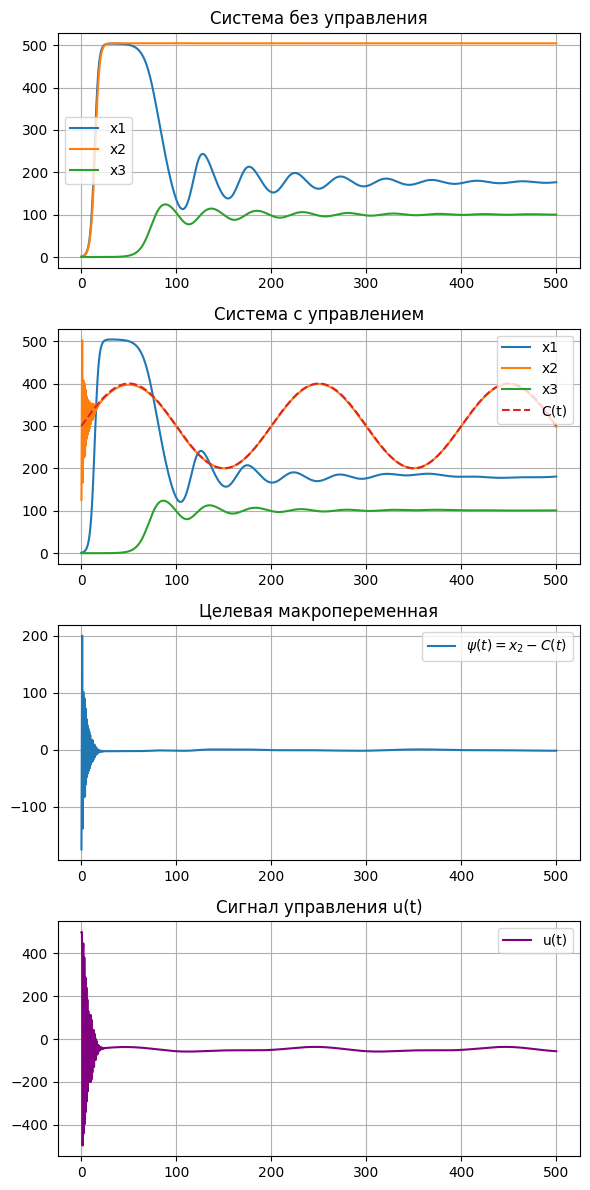

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

demo_x = np.array([[1.0, 1.0, 0.1]], np.float32)

def C_time_sinus(t_array, C_base=100.0, amp=20.0, period=200.0):
    # базовое + синусоида
    return C_base + amp * np.sin(2 * np.pi * t_array / period)

C_vals = C_time_sinus(ts, C_base=300.0, amp=100.0, period=200.0)

C_traj_np = C_vals.reshape((len(ts), 1, 1)).astype(np.float32)
C_traj_tf = tf.constant(C_traj_np)

def simulate_with_u_timeC(x0, C_traj, controller, params):
    batch = tf.shape(x0)[0]
    h1 = tf.zeros([batch, 32]); h2 = tf.zeros([batch, 32])
    x = x0
    traj = tf.TensorArray(tf.float32, size=len(ts))
    u_traj = tf.TensorArray(tf.float32, size=len(ts))
    C_out = tf.TensorArray(tf.float32, size=len(ts))
    for i in tf.range(len(ts)):
        x_norm = x / X_SCALE
        C_i = C_traj[i]
        C_norm = C_i / C_SCALE
        u_norm, h1, h2 = controller.step(x_norm, C_norm, h1, h2)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, params)
        x = x + dt * dx
        traj = traj.write(i, x)
        u_traj = u_traj.write(i, u_scaled)
        C_out = C_out.write(i, tf.reshape(C_i, [batch]))
    return tf.transpose(traj.stack(), [1,0,2]), tf.transpose(u_traj.stack(), [1,0]), tf.transpose(C_out.stack(), [1,0])

# без управления
traj_no = simulate_no_control(demo_x, system_params).numpy()[0]

traj_ctrl_tf, u_traj_tf, C_traj_back_tf = simulate_with_u_timeC(tf.constant(demo_x), C_traj_tf, controller, system_params)
traj_ctrl = traj_ctrl_tf.numpy()[0]
u_traj = u_traj_tf.numpy()[0]
C_traj_back = C_traj_back_tf.numpy()[0]

psi = traj_ctrl[:,1] - C_traj_back

plt.figure(figsize=(6,12))

plt.subplot(4,1,1)
plt.plot(ts, traj_no[:,0], label='x1')
plt.plot(ts, traj_no[:,1], label='x2')
plt.plot(ts, traj_no[:,2], label='x3')
plt.title("Система без управления")
plt.grid(); plt.legend()

ax = plt.subplot(4,1,2)
ax.plot(ts, traj_ctrl[:,0], label='x1')
ax.plot(ts, traj_ctrl[:,1], label='x2')
ax.plot(ts, traj_ctrl[:,2], label='x3')
ax.plot(ts, C_traj_back, '--', label='C(t)')
ax.grid()

# общие границы
ymin = min(np.nanmin(traj_ctrl), np.nanmin(C_traj_back))
ymax = max(np.nanmax(traj_ctrl), np.nanmax(C_traj_back))
pad = 0.05 * (ymax - ymin) if (ymax - ymin) != 0 else 1.0
ax.set_ylim(ymin - pad, ymax + pad)

ax.legend(loc='upper right')
ax.set_title("Система с управлением")

plt.subplot(4,1,3)
plt.plot(ts, psi, label=r'$\psi(t)=x_2-C(t)$')
plt.title("Целевая макропеременная")
plt.grid(); plt.legend()

plt.subplot(4,1,4)
plt.plot(ts, u_traj, label='u(t)', color='purple')
plt.title("Сигнал управления u(t)")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()


система с маленькими начальными условиями

Веса успешно загружены


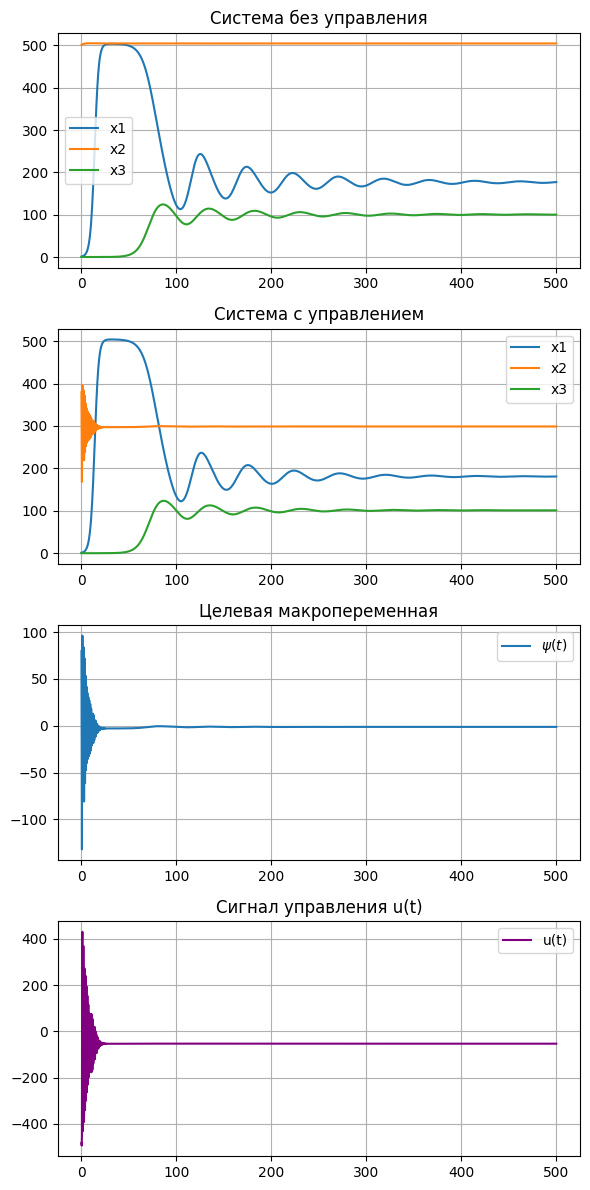

In [ ]:
controller = Controller()

# "строим" модель через call
_dummy_x = tf.zeros((1,3))
_dummy_C = tf.zeros((1,1))
_dummy_h = tf.zeros((1,32))
_ = controller((_dummy_x / X_SCALE, _dummy_C / C_SCALE, _dummy_h, _dummy_h))

# загружаем веса
controller.load_weights("/content/drive/MyDrive/controller_weights.weights.h5")
print("Веса успешно загружены")

def simulate_with_u(x0, C, controller, params):
    batch = tf.shape(x0)[0]
    h1 = tf.zeros([batch, 32]); h2 = tf.zeros([batch, 32])
    x = x0
    traj = tf.TensorArray(tf.float32, size=N)
    u_traj = tf.TensorArray(tf.float32, size=N)
    for i in tf.range(N):
        x_norm = x / X_SCALE
        C_norm = C / C_SCALE
        u_norm, h1, h2 = controller.step(x_norm, C_norm, h1, h2)   # normalized in
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, params)
        x = x + dt * dx
        traj = traj.write(i, x)
        u_traj = u_traj.write(i, u_scaled)   # сохраняем реальное u
    return tf.transpose(traj.stack(), [1,0,2]), tf.transpose(u_traj.stack(), [1,0])

# симуляция без управления
def simulate_no_control(x0, params):
    x = tf.identity(x0)
    traj = tf.TensorArray(tf.float32, size=N)
    for i in tf.range(N):
        dx = dynamics(x, tf.zeros((tf.shape(x)[0],)), params)
        x = x + dt * dx
        traj = traj.write(i, x)
    return tf.transpose(traj.stack(), [1,0,2])

# демонстрация
demo_x = np.array([[1.0, 500.0, 0.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)                    # здесь можно поменять целевое значение

traj_no = simulate_no_control(demo_x, system_params).numpy()[0]
traj_ctrl, u_traj = simulate_with_u(demo_x, demo_C, controller, system_params)
traj_ctrl, u_traj = traj_ctrl.numpy()[0], u_traj.numpy()[0]
psi = traj_ctrl[:,1] - demo_C[0]

# графики
plt.figure(figsize=(6,12))

plt.subplot(4,1,1)
plt.plot(ts, traj_no[:,0], label='x1')
plt.plot(ts, traj_no[:,1], label='x2')
plt.plot(ts, traj_no[:,2], label='x3')
plt.title("Система без управления")
plt.grid(); plt.legend()

plt.subplot(4,1,2)
plt.plot(ts, traj_ctrl[:,0], label='x1')
plt.plot(ts, traj_ctrl[:,1], label='x2')
plt.plot(ts, traj_ctrl[:,2], label='x3')
plt.title("Система с управлением")
plt.grid(); plt.legend()

plt.subplot(4,1,3)
plt.plot(ts, psi, label=r'$\psi(t)$')
plt.title("Целевая макропеременная")
plt.grid(); plt.legend()

plt.subplot(4,1,4)
plt.plot(ts, u_traj, label='u(t)', color='purple')
plt.title("Сигнал управления u(t)")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

смена синуса

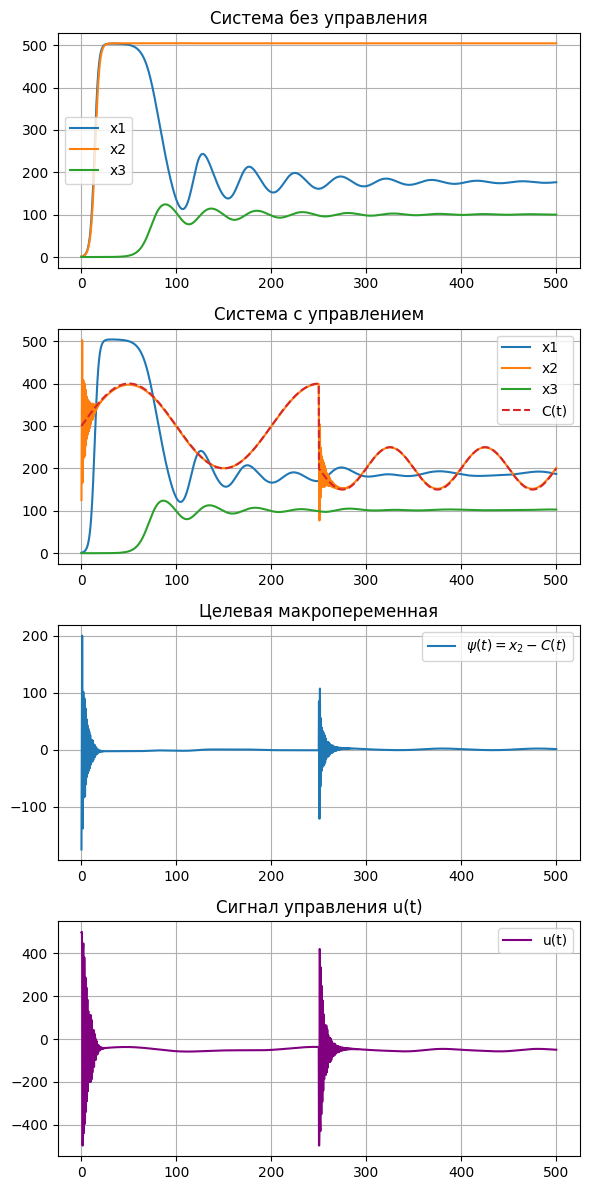

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

demo_x = np.array([[1.0, 1.0, 0.1]], np.float32)

def C_time_sinus(t_array,
                          t_switch=250.0,
                          C1_base=300.0, amp1=100.0, period1=200.0,
                          C2_base=200.0, amp2=50.0, period2=100.0):

    C_vals = np.zeros_like(t_array, dtype=np.float32)

    # первая синусоида до переключения
    idx1 = t_array < t_switch
    C_vals[idx1] = C1_base + amp1 * np.sin(2 * np.pi * t_array[idx1] / period1)

    # вторая синусоида после переключения
    idx2 = ~idx1
    C_vals[idx2] = C2_base + amp2 * np.sin(2 * np.pi * t_array[idx2] / period2)

    return C_vals

C_vals = C_time_sinus(
    ts,
    t_switch=250.0,
    C1_base=300.0, amp1=100.0, period1=200.0,
    C2_base=200.0, amp2=50.0, period2=100.0
)


C_traj_np = C_vals.reshape((len(ts), 1, 1)).astype(np.float32)
C_traj_tf = tf.constant(C_traj_np)

def simulate_with_u_timeC(x0, C_traj, controller, params):
    batch = tf.shape(x0)[0]
    h1 = tf.zeros([batch, 32]); h2 = tf.zeros([batch, 32])
    x = x0
    traj = tf.TensorArray(tf.float32, size=len(ts))
    u_traj = tf.TensorArray(tf.float32, size=len(ts))
    C_out = tf.TensorArray(tf.float32, size=len(ts))
    for i in tf.range(len(ts)):
        x_norm = x / X_SCALE
        C_i = C_traj[i]
        C_norm = C_i / C_SCALE
        u_norm, h1, h2 = controller.step(x_norm, C_norm, h1, h2)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, params)
        x = x + dt * dx
        traj = traj.write(i, x)
        u_traj = u_traj.write(i, u_scaled)
        C_out = C_out.write(i, tf.reshape(C_i, [batch]))
    return tf.transpose(traj.stack(), [1,0,2]), tf.transpose(u_traj.stack(), [1,0]), tf.transpose(C_out.stack(), [1,0])

# без управления
traj_no = simulate_no_control(demo_x, system_params).numpy()[0]

traj_ctrl_tf, u_traj_tf, C_traj_back_tf = simulate_with_u_timeC(tf.constant(demo_x), C_traj_tf, controller, system_params)
traj_ctrl = traj_ctrl_tf.numpy()[0]
u_traj = u_traj_tf.numpy()[0]
C_traj_back = C_traj_back_tf.numpy()[0]

psi = traj_ctrl[:,1] - C_traj_back

plt.figure(figsize=(6,12))

plt.subplot(4,1,1)
plt.plot(ts, traj_no[:,0], label='x1')
plt.plot(ts, traj_no[:,1], label='x2')
plt.plot(ts, traj_no[:,2], label='x3')
plt.title("Система без управления")
plt.grid(); plt.legend()

ax = plt.subplot(4,1,2)
ax.plot(ts, traj_ctrl[:,0], label='x1')
ax.plot(ts, traj_ctrl[:,1], label='x2')
ax.plot(ts, traj_ctrl[:,2], label='x3')
ax.plot(ts, C_traj_back, '--', label='C(t)')
ax.grid()

# общие границы
ymin = min(np.nanmin(traj_ctrl), np.nanmin(C_traj_back))
ymax = max(np.nanmax(traj_ctrl), np.nanmax(C_traj_back))
pad = 0.05 * (ymax - ymin) if (ymax - ymin) != 0 else 1.0
ax.set_ylim(ymin - pad, ymax + pad)

ax.legend(loc='upper right')
ax.set_title("Система с управлением")

plt.subplot(4,1,3)
plt.plot(ts, psi, label=r'$\psi(t)=x_2-C(t)$')
plt.title("Целевая макропеременная")
plt.grid(); plt.legend()

plt.subplot(4,1,4)
plt.plot(ts, u_traj, label='u(t)', color='purple')
plt.title("Сигнал управления u(t)")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()
